In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df= pd.read_csv('data/data.csv')
df

,DATE,VISIBILITY,DRYBULBTEMPF,WETBULBTEMPF,DewPointTempF,RelativeHumidity,WindSpeed,WindDirection,StationPressure,SeaLevelPressure,Precip
0,2010-01-01 00:51:00,6.0,33,32,31,92,0,0,29.97,29.99,0.01
1,2010-01-01 01:51:00,6.0,33,33,32,96,0,0,29.97,29.99,0.02
2,2010-01-01 02:51:00,5.0,33,33,32,96,0,0,29.97,29.99,0.02
3,2010-01-01 03:51:00,5.0,33,33,32,96,0,0,29.95,29.97,0.02
4,2010-01-01 04:51:00,5.0,33,32,31,92,0,0,29.93,29.96,0.02
...,...,...,...,...,...,...,...,...,...,...,...
75078,2018-07-27 18:51:00,10.0,76,73,72,88,3,230,30.00,30.02,0.00
75079,2018-07-27 19:51:00,4.0,69,69,69,100,13,40,29.99,30.01,1.16
75080,2018-07-27 20:51:00,10.0,71,70,70,96,0,0,30.02,30.04,0.01
75081,2018-07-27 21:51:00,10.0,72,71,70,94,5,50,30.00,30.02,0.01


In [3]:
df.head()

,DATE,VISIBILITY,DRYBULBTEMPF,WETBULBTEMPF,DewPointTempF,RelativeHumidity,WindSpeed,WindDirection,StationPressure,SeaLevelPressure,Precip
0,2010-01-01 00:51:00,6.0,33,32,31,92,0,0,29.97,29.99,0.01
1,2010-01-01 01:51:00,6.0,33,33,32,96,0,0,29.97,29.99,0.02
2,2010-01-01 02:51:00,5.0,33,33,32,96,0,0,29.97,29.99,0.02
3,2010-01-01 03:51:00,5.0,33,33,32,96,0,0,29.95,29.97,0.02
4,2010-01-01 04:51:00,5.0,33,32,31,92,0,0,29.93,29.96,0.02


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 75083 entries, 0 to 75082
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   DATE              75083 non-null  str    
 1   VISIBILITY        75083 non-null  float64
 2   DRYBULBTEMPF      75083 non-null  int64  
 3   WETBULBTEMPF      75083 non-null  int64  
 4   DewPointTempF     75083 non-null  int64  
 5   RelativeHumidity  75083 non-null  int64  
 6   WindSpeed         75083 non-null  int64  
 7   WindDirection     75083 non-null  int64  
 8   StationPressure   75083 non-null  float64
 9   SeaLevelPressure  75083 non-null  float64
 10  Precip            75083 non-null  float64
dtypes: float64(4), int64(6), str(1)
memory usage: 6.3 MB


In [5]:
df['DATE'] = pd.to_datetime(df['DATE'],format='%Y-%m-%d %H:%M:%S')


In [6]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 75083 entries, 0 to 75082
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   DATE              75083 non-null  datetime64[us]
 1   VISIBILITY        75083 non-null  float64       
 2   DRYBULBTEMPF      75083 non-null  int64         
 3   WETBULBTEMPF      75083 non-null  int64         
 4   DewPointTempF     75083 non-null  int64         
 5   RelativeHumidity  75083 non-null  int64         
 6   WindSpeed         75083 non-null  int64         
 7   WindDirection     75083 non-null  int64         
 8   StationPressure   75083 non-null  float64       
 9   SeaLevelPressure  75083 non-null  float64       
 10  Precip            75083 non-null  float64       
dtypes: datetime64[us](1), float64(4), int64(6)
memory usage: 6.3 MB


# Categorical column and Numerical column separation


In [7]:
columns = [column for column in df.columns if column !='VISIBILITY']
columns

['DATE',
 'DRYBULBTEMPF',
 'WETBULBTEMPF',
 'DewPointTempF',
 'RelativeHumidity',
 'WindSpeed',
 'WindDirection',
 'StationPressure',
 'SeaLevelPressure',
 'Precip']

In [8]:
num_column = [features for features in columns if df[features].dtypes !='o']
num_column

['DATE',
 'DRYBULBTEMPF',
 'WETBULBTEMPF',
 'DewPointTempF',
 'RelativeHumidity',
 'WindSpeed',
 'WindDirection',
 'StationPressure',
 'SeaLevelPressure',
 'Precip']

In [9]:
cat_column = [features for features in columns if df[features].dtypes == 'o']
cat_column

[]

In [10]:
print("There are {} numerical columns:{}".format(len(num_column),num_column))
print("\n There are {} categorical columns:{}".format(len(cat_column),cat_column))

There are 10 numerical columns:['DATE', 'DRYBULBTEMPF', 'WETBULBTEMPF', 'DewPointTempF', 'RelativeHumidity', 'WindSpeed', 'WindDirection', 'StationPressure', 'SeaLevelPressure', 'Precip']

 There are 0 categorical columns:[]


# Univariate Analysis

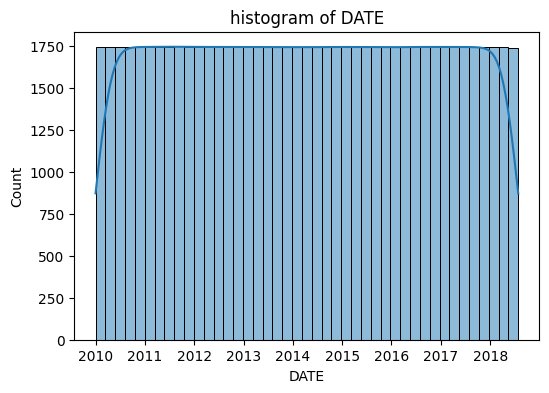

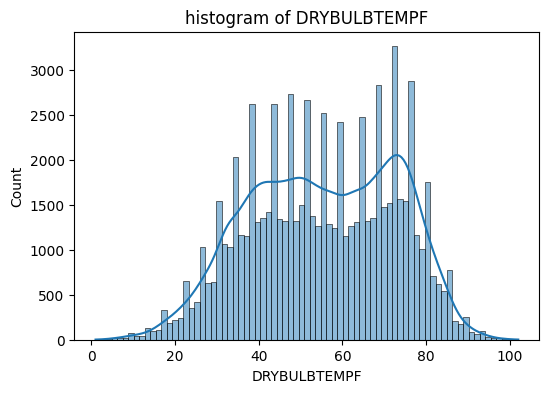

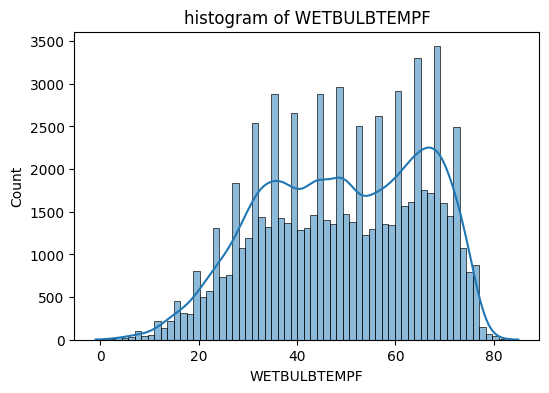

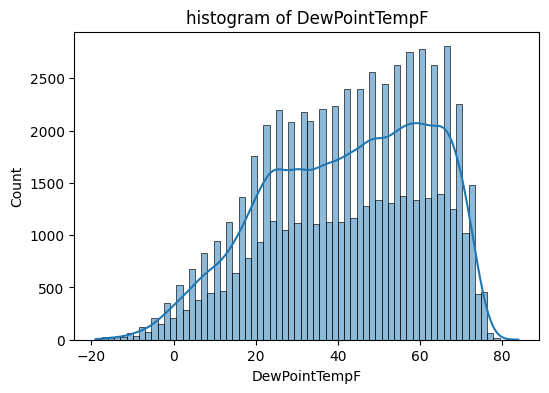

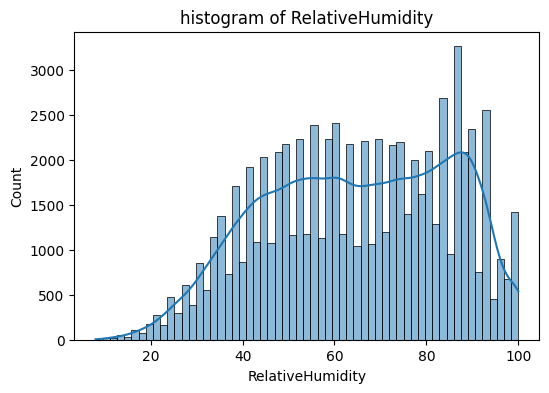

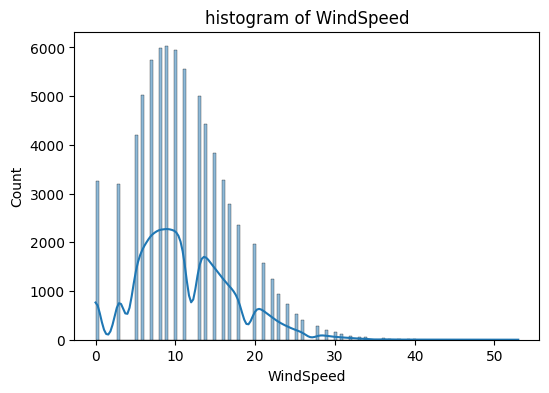

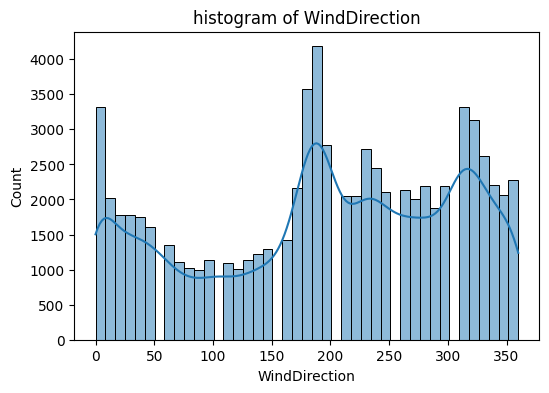

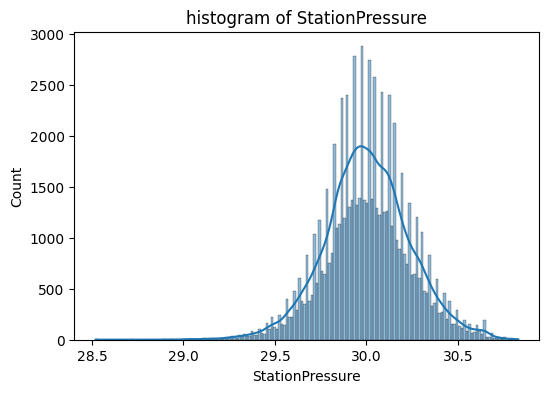

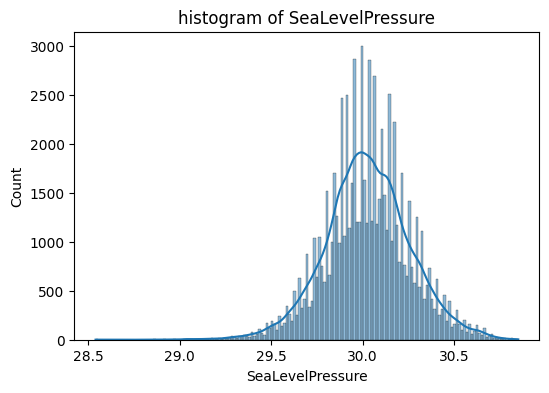

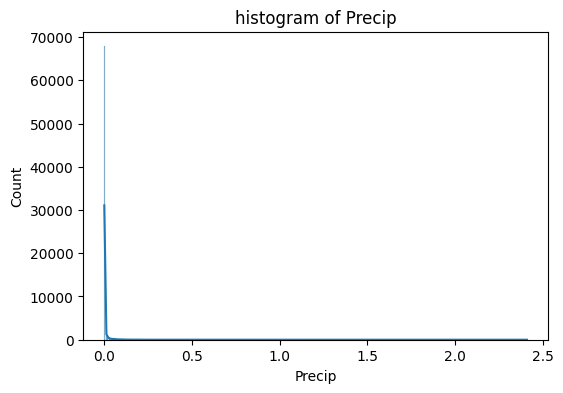

In [11]:
for column in num_column:
    plt.figure(figsize=(6,4))
    sns.histplot(df[column],kde=True)
    plt.title(f"histogram of {column}")

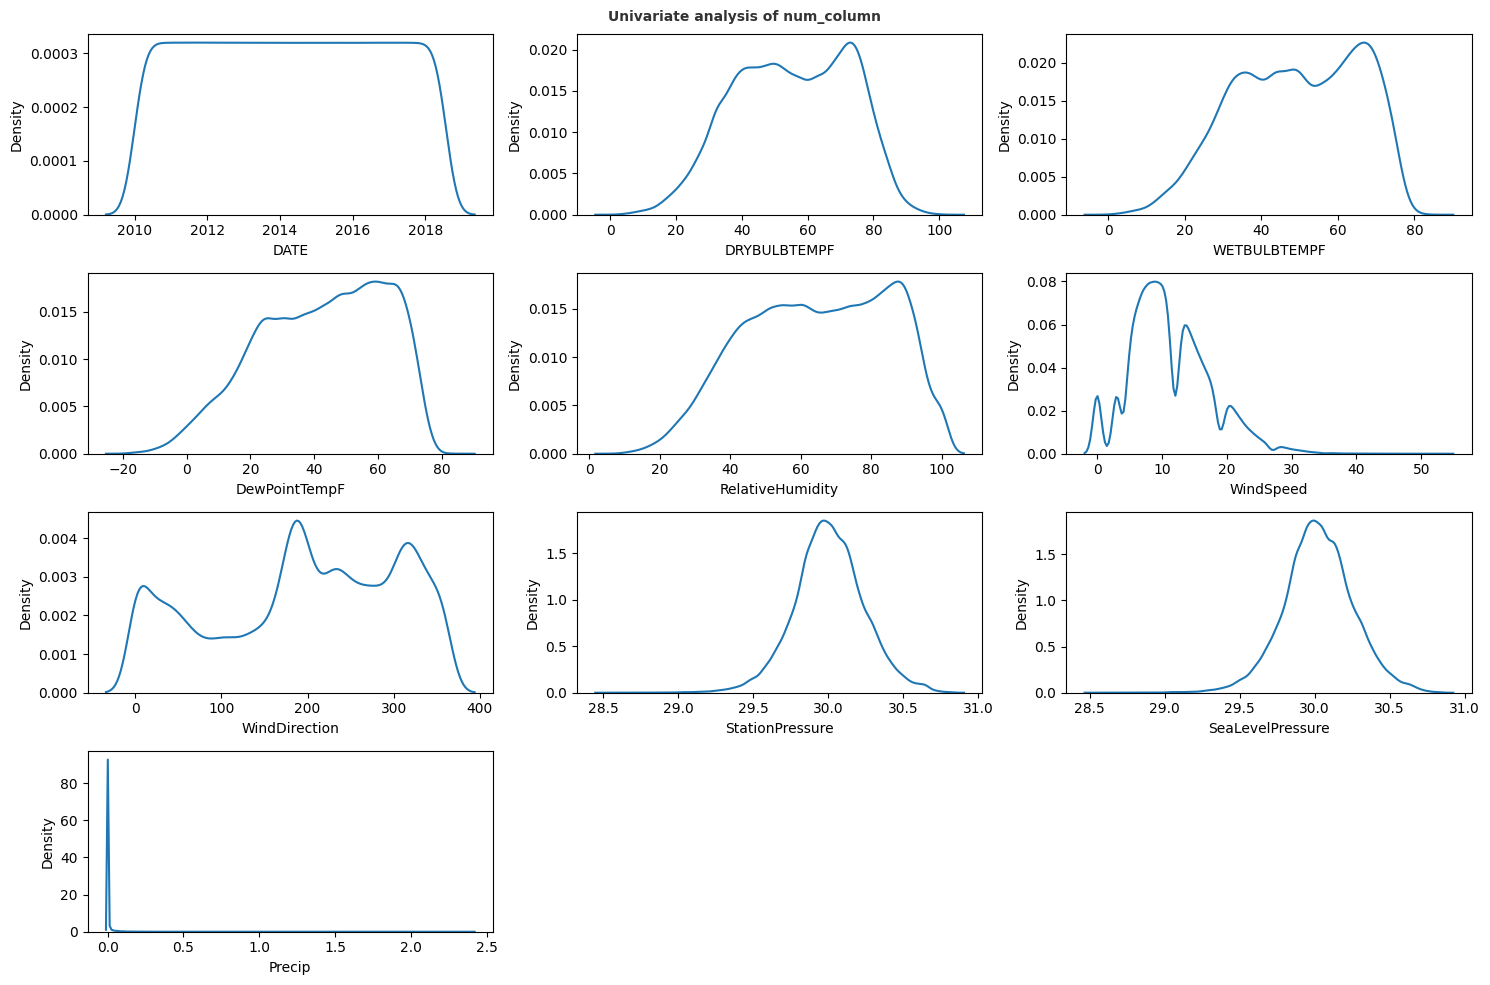

In [12]:
plt.figure(figsize=(15,10))
plt.suptitle("Univariate analysis of num_column",fontweight='bold',fontsize=10,alpha=0.8)
for i in range(0,len(num_column)):
    plt.subplot(4,3,i+1)
    sns.kdeplot(x=df[num_column[i]])
    plt.xlabel(num_column[i])
    plt.tight_layout()

In [13]:
df = df.drop(columns='Precip')


In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 75083 entries, 0 to 75082
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   DATE              75083 non-null  datetime64[us]
 1   VISIBILITY        75083 non-null  float64       
 2   DRYBULBTEMPF      75083 non-null  int64         
 3   WETBULBTEMPF      75083 non-null  int64         
 4   DewPointTempF     75083 non-null  int64         
 5   RelativeHumidity  75083 non-null  int64         
 6   WindSpeed         75083 non-null  int64         
 7   WindDirection     75083 non-null  int64         
 8   StationPressure   75083 non-null  float64       
 9   SeaLevelPressure  75083 non-null  float64       
dtypes: datetime64[us](1), float64(3), int64(6)
memory usage: 5.7 MB


In [15]:
df['year'] = df['DATE'].dt.year
df['month'] = df['DATE'].dt.month
df['day'] = df['DATE'].dt.day
df['hour'] = df['DATE'].dt.hour

In [16]:
df


,DATE,VISIBILITY,DRYBULBTEMPF,WETBULBTEMPF,DewPointTempF,RelativeHumidity,WindSpeed,WindDirection,StationPressure,SeaLevelPressure,year,month,day,hour
0,2010-01-01 00:51:00,6.0,33,32,31,92,0,0,29.97,29.99,2010,1,1,0
1,2010-01-01 01:51:00,6.0,33,33,32,96,0,0,29.97,29.99,2010,1,1,1
2,2010-01-01 02:51:00,5.0,33,33,32,96,0,0,29.97,29.99,2010,1,1,2
3,2010-01-01 03:51:00,5.0,33,33,32,96,0,0,29.95,29.97,2010,1,1,3
4,2010-01-01 04:51:00,5.0,33,32,31,92,0,0,29.93,29.96,2010,1,1,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75078,2018-07-27 18:51:00,10.0,76,73,72,88,3,230,30.00,30.02,2018,7,27,18
75079,2018-07-27 19:51:00,4.0,69,69,69,100,13,40,29.99,30.01,2018,7,27,19
75080,2018-07-27 20:51:00,10.0,71,70,70,96,0,0,30.02,30.04,2018,7,27,20
75081,2018-07-27 21:51:00,10.0,72,71,70,94,5,50,30.00,30.02,2018,7,27,21


In [17]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 75083 entries, 0 to 75082
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   DATE              75083 non-null  datetime64[us]
 1   VISIBILITY        75083 non-null  float64       
 2   DRYBULBTEMPF      75083 non-null  int64         
 3   WETBULBTEMPF      75083 non-null  int64         
 4   DewPointTempF     75083 non-null  int64         
 5   RelativeHumidity  75083 non-null  int64         
 6   WindSpeed         75083 non-null  int64         
 7   WindDirection     75083 non-null  int64         
 8   StationPressure   75083 non-null  float64       
 9   SeaLevelPressure  75083 non-null  float64       
 10  year              75083 non-null  int32         
 11  month             75083 non-null  int32         
 12  day               75083 non-null  int32         
 13  hour              75083 non-null  int32         
dtypes: datetime64[us](1), float64(3),

# Multivariate analysis


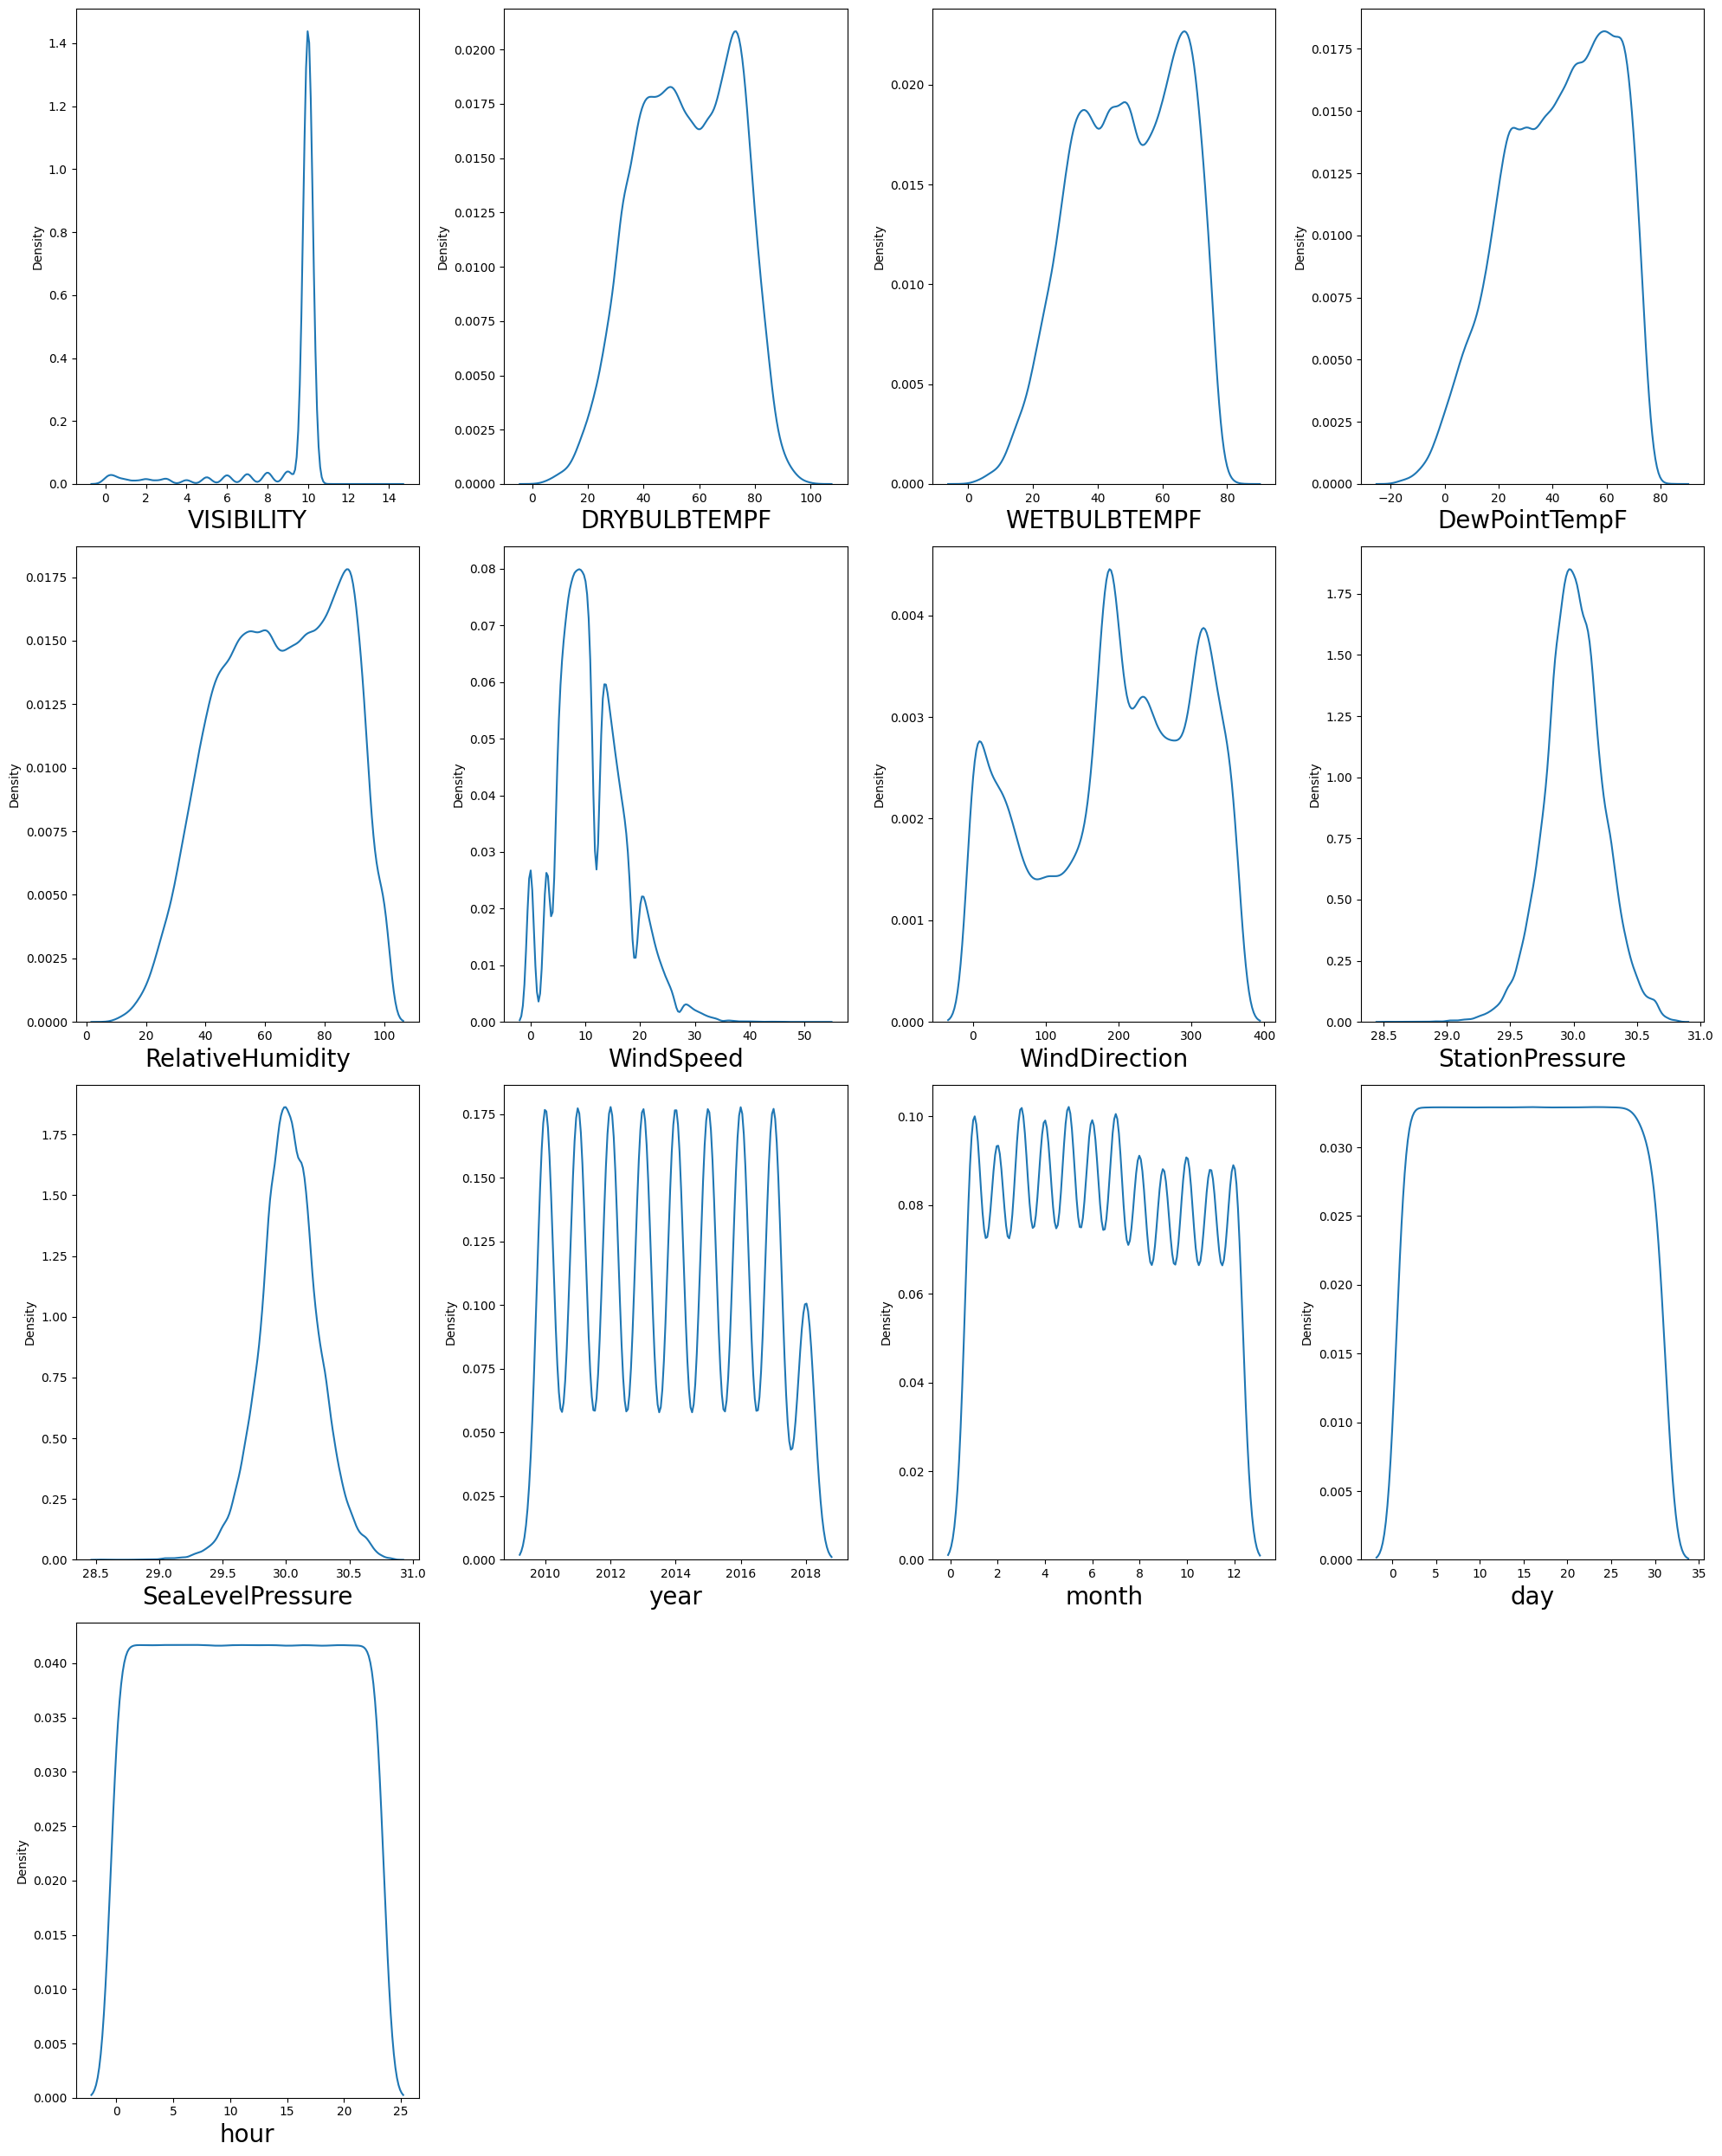

In [18]:
plt.figure(figsize=(20,25), facecolor='white')
plotnumber = 1

for column in df.drop(['DATE'],axis=1):
    ax = plt.subplot(4,4,plotnumber)
    sns.kdeplot(df[column])
    plt.xlabel(column,fontsize=20)
        #plt.ylabel('Salary',fontsize=20)
    plotnumber+=1
plt.tight_layout()

In [19]:
df['hour'] = df['DATE'].dt.hour
df

,DATE,VISIBILITY,DRYBULBTEMPF,WETBULBTEMPF,DewPointTempF,RelativeHumidity,WindSpeed,WindDirection,StationPressure,SeaLevelPressure,year,month,day,hour
0,2010-01-01 00:51:00,6.0,33,32,31,92,0,0,29.97,29.99,2010,1,1,0
1,2010-01-01 01:51:00,6.0,33,33,32,96,0,0,29.97,29.99,2010,1,1,1
2,2010-01-01 02:51:00,5.0,33,33,32,96,0,0,29.97,29.99,2010,1,1,2
3,2010-01-01 03:51:00,5.0,33,33,32,96,0,0,29.95,29.97,2010,1,1,3
4,2010-01-01 04:51:00,5.0,33,32,31,92,0,0,29.93,29.96,2010,1,1,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75078,2018-07-27 18:51:00,10.0,76,73,72,88,3,230,30.00,30.02,2018,7,27,18
75079,2018-07-27 19:51:00,4.0,69,69,69,100,13,40,29.99,30.01,2018,7,27,19
75080,2018-07-27 20:51:00,10.0,71,70,70,96,0,0,30.02,30.04,2018,7,27,20
75081,2018-07-27 21:51:00,10.0,72,71,70,94,5,50,30.00,30.02,2018,7,27,21


In [20]:
df.drop(columns=('DATE'),inplace=True)


In [21]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 75083 entries, 0 to 75082
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   VISIBILITY        75083 non-null  float64
 1   DRYBULBTEMPF      75083 non-null  int64  
 2   WETBULBTEMPF      75083 non-null  int64  
 3   DewPointTempF     75083 non-null  int64  
 4   RelativeHumidity  75083 non-null  int64  
 5   WindSpeed         75083 non-null  int64  
 6   WindDirection     75083 non-null  int64  
 7   StationPressure   75083 non-null  float64
 8   SeaLevelPressure  75083 non-null  float64
 9   year              75083 non-null  int32  
 10  month             75083 non-null  int32  
 11  day               75083 non-null  int32  
 12  hour              75083 non-null  int32  
dtypes: float64(3), int32(4), int64(6)
memory usage: 6.3 MB


# Variance analysis using heatmap


<Axes: >

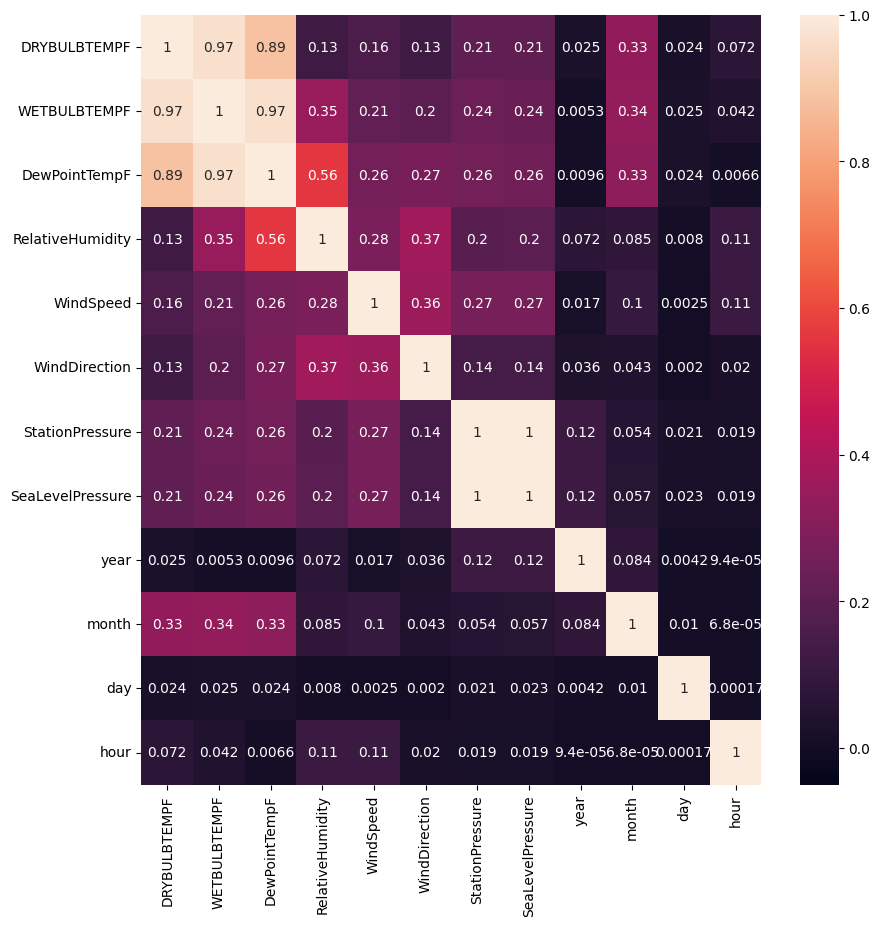

In [22]:
plt.figure(figsize=(10,10))
new_df = df.drop(columns=('VISIBILITY'))
sns.heatmap(new_df.corr().abs(),vmin=-.05,vmax=1,annot=True)

In [23]:
df=df.drop(columns=['StationPressure','DewPointTempF','WETBULBTEMPF'])


In [24]:
df

,VISIBILITY,DRYBULBTEMPF,RelativeHumidity,WindSpeed,WindDirection,SeaLevelPressure,year,month,day,hour
0,6.0,33,92,0,0,29.99,2010,1,1,0
1,6.0,33,96,0,0,29.99,2010,1,1,1
2,5.0,33,96,0,0,29.99,2010,1,1,2
3,5.0,33,96,0,0,29.97,2010,1,1,3
4,5.0,33,92,0,0,29.96,2010,1,1,4
...,...,...,...,...,...,...,...,...,...,...
75078,10.0,76,88,3,230,30.02,2018,7,27,18
75079,4.0,69,100,13,40,30.01,2018,7,27,19
75080,10.0,71,96,0,0,30.04,2018,7,27,20
75081,10.0,72,94,5,50,30.02,2018,7,27,21


<Axes: >

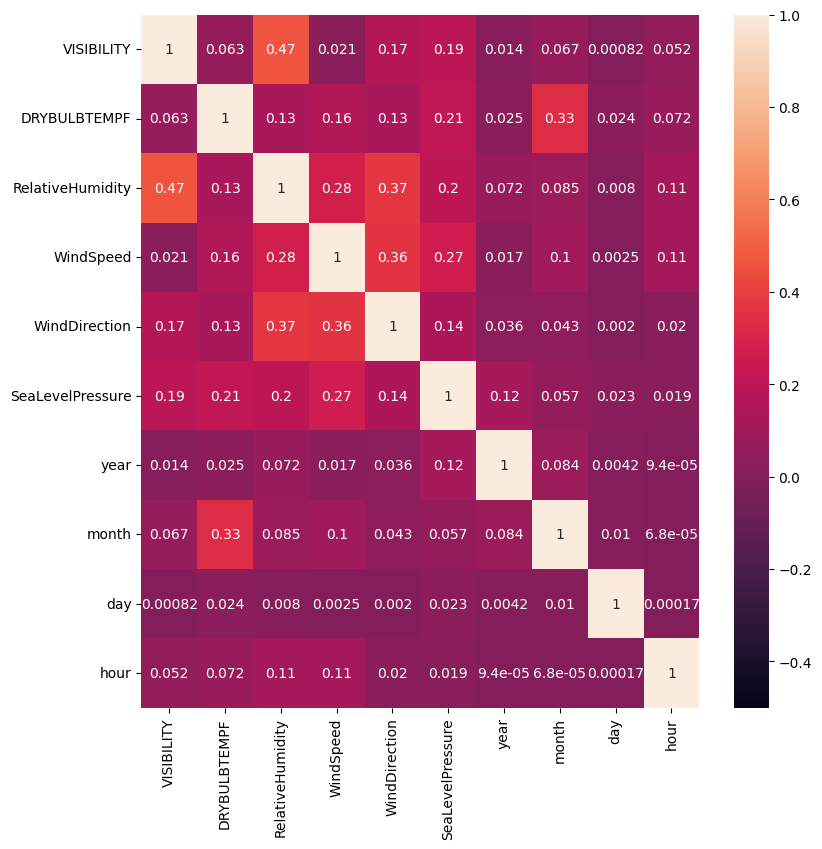

In [25]:
plt.figure(figsize=(9,9))
plt_df=df
sns.heatmap(plt_df.corr().abs(),vmin=-0.5,vmax=1,annot=True)

In [26]:
df.columns


Index(['VISIBILITY', 'DRYBULBTEMPF', 'RelativeHumidity', 'WindSpeed',
       'WindDirection', 'SeaLevelPressure', 'year', 'month', 'day', 'hour'],
      dtype='str')

# Multicollinearity checking


In [28]:
pip install statsmodels


  Obtaining dependency information for statsmodels from https://files.pythonhosted.org/packages/60/15/3daba2df40be8b8a9a027d7f54c8dedf24f0d81b96e54b52293f5f7e3418/statsmodels-0.14.6-cp312-cp312-win_amd64.whl.metadata
  Using cached statsmodels-0.14.6-cp312-cp312-win_amd64.whl.metadata (9.8 kB)
  Obtaining dependency information for patsy>=0.5.6 from https://files.pythonhosted.org/packages/f1/70/ba4b949bdc0490ab78d545459acd7702b211dfccf7eb89bbc1060f52818d/patsy-1.0.2-py2.py3-none-any.whl.metadata
  Using cached patsy-1.0.2-py2.py3-none-any.whl.metadata (3.6 kB)
Using cached statsmodels-0.14.6-cp312-cp312-win_amd64.whl (9.5 MB)
Using cached patsy-1.0.2-py2.py3-none-any.whl (233 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [29]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
def compute_vif(considered_features, df):
    
    X = df[considered_features]
    # the calculation of variance inflation requires a constant
    X['intercept'] = 1
    
    # create dataframe to store vif values
    vif = pd.DataFrame()
    vif["Variable"] = X.columns
    vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    vif = vif[vif['Variable']!='intercept']
    return vif

        
#we will remove the datetime column which is not required for the vif checking
features = df.columns.to_list()
# features.pop(features.index('DATE'))

compute_vif(features, df)

,Variable,VIF
0,VISIBILITY,1.350279
1,DRYBULBTEMPF,1.301073
2,RelativeHumidity,1.671284
3,WindSpeed,1.373461
4,WindDirection,1.316028
5,SeaLevelPressure,1.382411
6,year,1.047027
7,month,1.175268
8,day,1.000962
9,hour,1.032177


In [30]:
df.isna().sum()


VISIBILITY          0
DRYBULBTEMPF        0
RelativeHumidity    0
WindSpeed           0
WindDirection       0
SeaLevelPressure    0
year                0
month               0
day                 0
hour                0
dtype: int64

In [31]:
num_column


['DATE',
 'DRYBULBTEMPF',
 'WETBULBTEMPF',
 'DewPointTempF',
 'RelativeHumidity',
 'WindSpeed',
 'WindDirection',
 'StationPressure',
 'SeaLevelPressure',
 'Precip']

In [32]:
cat_column

[]

In [33]:
for col in ['year', 'month', 'day', 'hour']:
    if col not in num_column:
        num_column.append(col)

In [34]:
num_column

['DATE',
 'DRYBULBTEMPF',
 'WETBULBTEMPF',
 'DewPointTempF',
 'RelativeHumidity',
 'WindSpeed',
 'WindDirection',
 'StationPressure',
 'SeaLevelPressure',
 'Precip',
 'year',
 'month',
 'day',
 'hour']

In [35]:
num_column = [col for col in num_column if col in df.columns]


In [36]:
num_column

['DRYBULBTEMPF',
 'RelativeHumidity',
 'WindSpeed',
 'WindDirection',
 'SeaLevelPressure',
 'year',
 'month',
 'day',
 'hour']

In [37]:
df.head()

,VISIBILITY,DRYBULBTEMPF,RelativeHumidity,WindSpeed,WindDirection,SeaLevelPressure,year,month,day,hour
0,6.0,33,92,0,0,29.99,2010,1,1,0
1,6.0,33,96,0,0,29.99,2010,1,1,1
2,5.0,33,96,0,0,29.99,2010,1,1,2
3,5.0,33,96,0,0,29.97,2010,1,1,3
4,5.0,33,92,0,0,29.96,2010,1,1,4


In [38]:
df.nunique()

VISIBILITY           20
DRYBULBTEMPF        102
RelativeHumidity     90
WindSpeed            43
WindDirection        37
SeaLevelPressure    202
year                  9
month                12
day                  31
hour                 24
dtype: int64

In [39]:
df.dtypes

VISIBILITY          float64
DRYBULBTEMPF          int64
RelativeHumidity      int64
WindSpeed             int64
WindDirection         int64
SeaLevelPressure    float64
year                  int32
month                 int32
day                   int32
hour                  int32
dtype: object

In [40]:
df['day'].value_counts()


day
2     2474
15    2473
24    2473
1     2472
16    2472
17    2472
19    2472
22    2472
23    2472
4     2471
5     2471
6     2471
10    2471
11    2471
26    2471
7     2470
8     2470
12    2470
13    2470
14    2470
21    2470
25    2470
9     2469
20    2469
18    2468
27    2468
3     2467
28    2447
29    2280
30    2231
31    1416
Name: count, dtype: int64

# Separating discrete and continuous features


In [41]:
continuous = []
discrete = []
categorical = []

for col in df.columns:
    
    # Skip target (optional but recommended)
    if col == 'VISIBILITY':
        continue

    # Categorical
    if df[col].dtype == 'object':
        categorical.append(col)
    
    # Numeric (handles int32, int64, float64 sab)
    elif np.issubdtype(df[col].dtype, np.number):
        
        # Time-based features → always discrete
        if col in ['year', 'month', 'day', 'hour']:
            discrete.append(col)
        
        # Low unique values → discrete
        elif df[col].nunique() <= 20:
            discrete.append(col)
        
        # Otherwise → continuous
        else:
            continuous.append(col)

print("Continuous:", continuous)
print("Discrete:", discrete)
print("Categorical:", categorical)

Continuous: ['DRYBULBTEMPF', 'RelativeHumidity', 'WindSpeed', 'WindDirection', 'SeaLevelPressure']
Discrete: ['year', 'month', 'day', 'hour']
Categorical: []


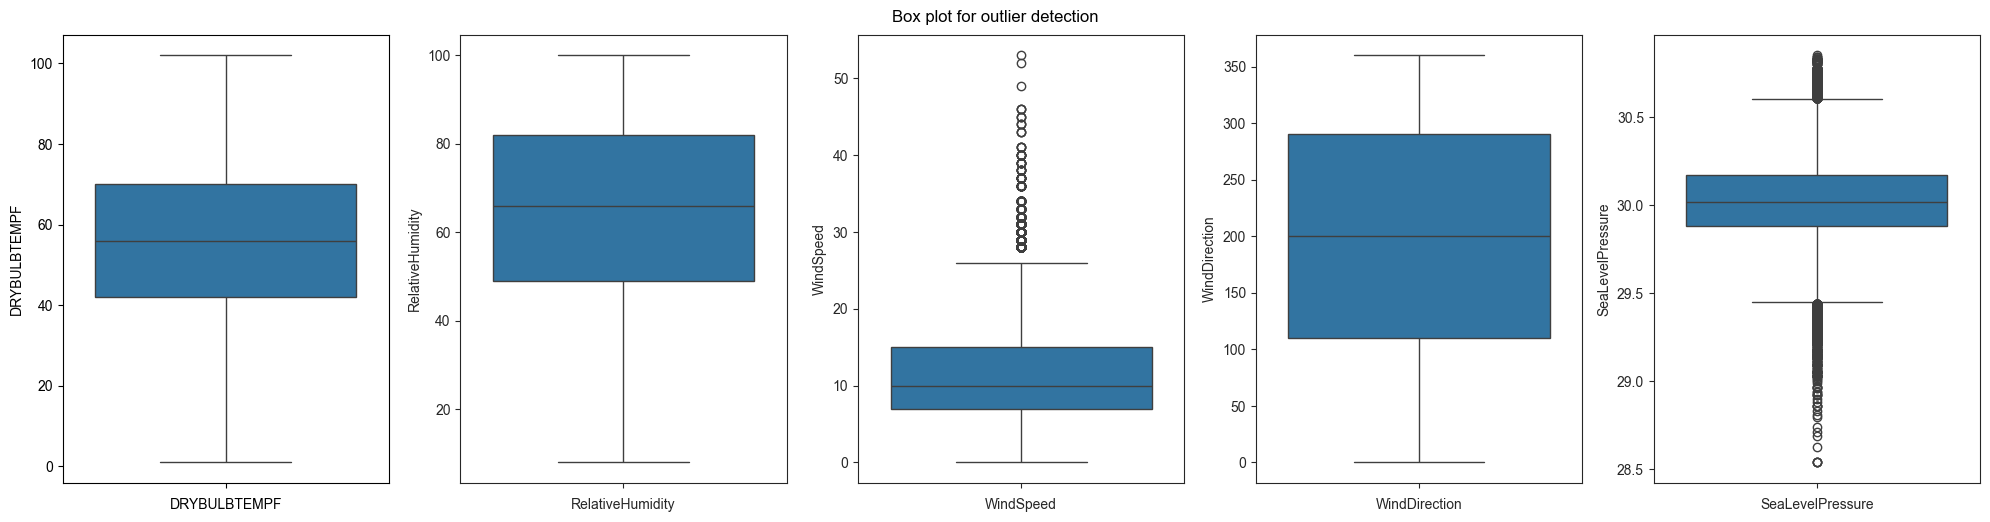

In [42]:
plt.figure(figsize=(20,10))
plt.suptitle("Box plot for outlier detection")
for i in range(len(continuous)):
    plt.subplot(2,5,i+1)
    sns.set_style('ticks')
    sns.boxplot(df[continuous[i]])
    plt.xlabel(continuous[i])
    plt.tight_layout()
    

# Capping of outliers

In [43]:
df[continuous] = df[continuous].astype(float) # ye error aane ke baad kiya hai kyuki after iqr kuch float values aarhi thi aur dtype kuch columns ka int hai apna isliye

def detect_outliers(col):
    # Finding the IQR
    percentile25 = df[col].quantile(0.25)
    percentile75 = df[col].quantile(0.75)
    print('\n ####', col , '####')
    print("percentile25",percentile25)
    print("percentile75",percentile75)
    iqr = percentile75 - percentile25  # Q3-Q1
    print("IQR",iqr)
    # Finding the upper and lower limits
    upper_limit = percentile75 + 1.5 * iqr  # Q3 + 1.5*IQR
    lower_limit = percentile25 - 1.5 * iqr  #Q1 - 1.5*IQR
    print("Upper limit",upper_limit)
    print("Lower limit",lower_limit)
    df.loc[(df[col]>upper_limit), col]= upper_limit
    df.loc[(df[col]<lower_limit), col]= lower_limit    
    return df




for col in continuous:
    detect_outliers(col=col)


 #### DRYBULBTEMPF ####
percentile25 42.0
percentile75 70.0
IQR 28.0
Upper limit 112.0
Lower limit 0.0

 #### RelativeHumidity ####
percentile25 49.0
percentile75 82.0
IQR 33.0
Upper limit 131.5
Lower limit -0.5

 #### WindSpeed ####
percentile25 7.0
percentile75 15.0
IQR 8.0
Upper limit 27.0
Lower limit -5.0

 #### WindDirection ####
percentile25 110.0
percentile75 290.0
IQR 180.0
Upper limit 560.0
Lower limit -160.0

 #### SeaLevelPressure ####
percentile25 29.88
percentile75 30.17
IQR 0.2900000000000027
Upper limit 30.605000000000004
Lower limit 29.444999999999993


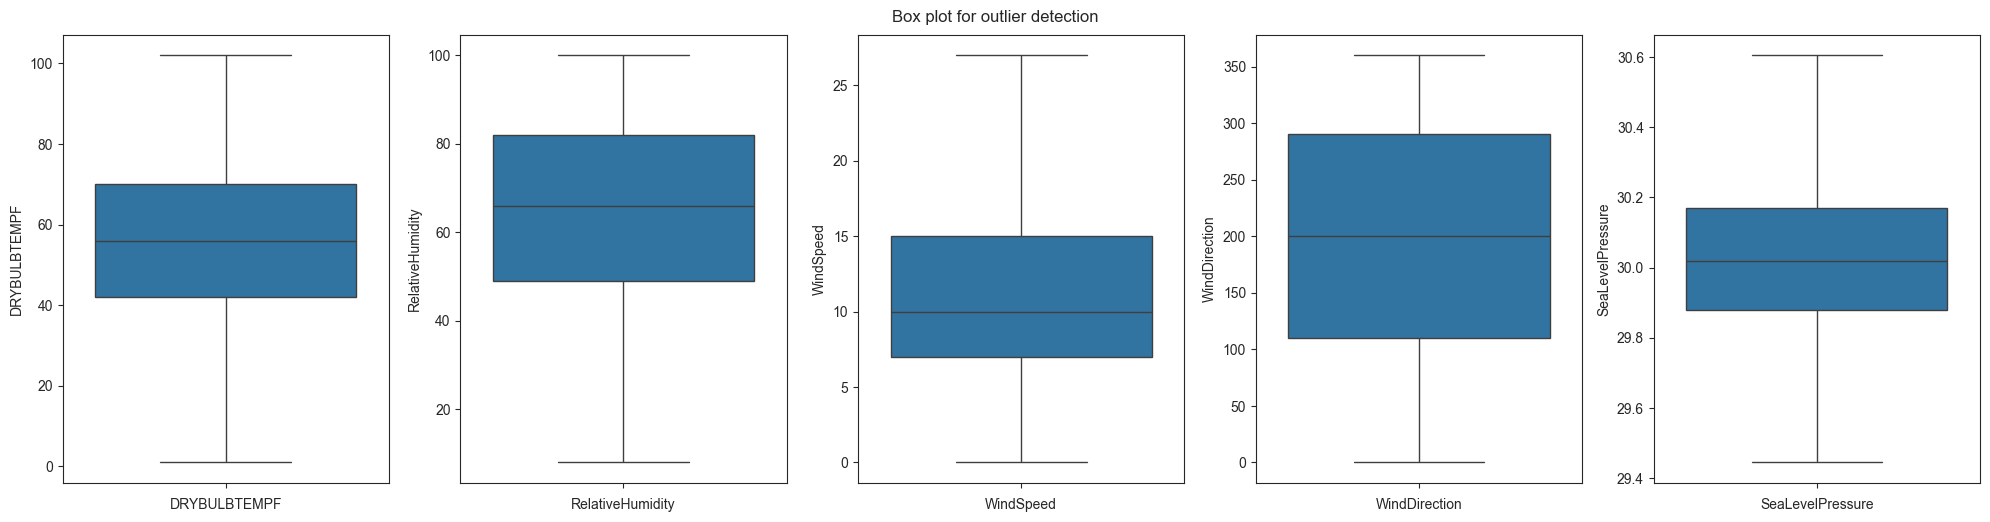

In [44]:
plt.figure(figsize=(20,10))
plt.suptitle("Box plot for outlier detection")
for i in range(len(continuous)):
    plt.subplot(2,5,i+1)
    sns.set_style('ticks')
    sns.boxplot(df[continuous[i]])
    plt.xlabel(continuous[i])
    plt.tight_layout()

In [45]:
df[continuous].skew(axis=0,skipna=True)


DRYBULBTEMPF       -0.149154
RelativeHumidity   -0.186890
WindSpeed           0.471627
WindDirection      -0.335758
SeaLevelPressure    0.005286
dtype: float64

| Skew Value | Meaning                             |
| ---------- | ----------------------------------- |
| ≈ 0        | Data symmetric hai                  |
| > 0        | Right side long tail (Right skewed) |
| < 0        | Left side long tail (Left skewed)   |

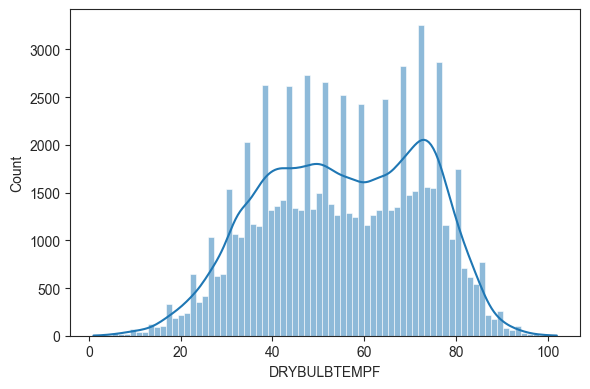

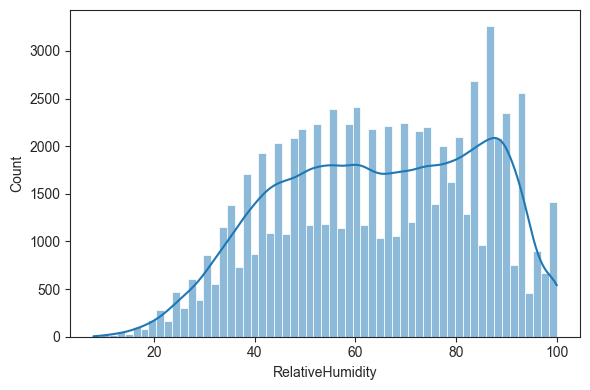

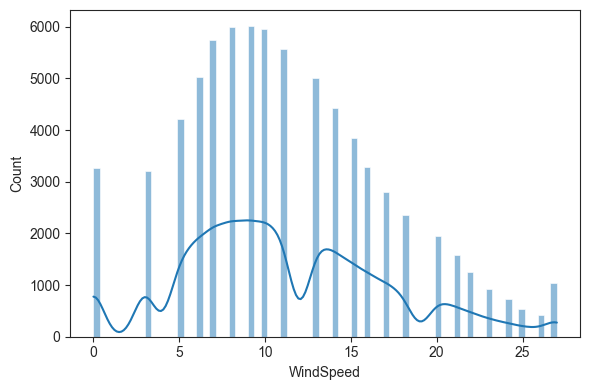

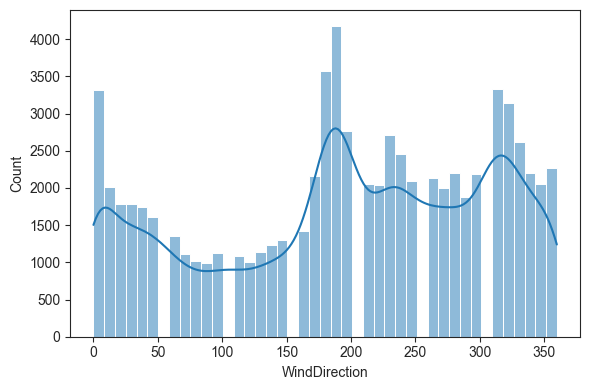

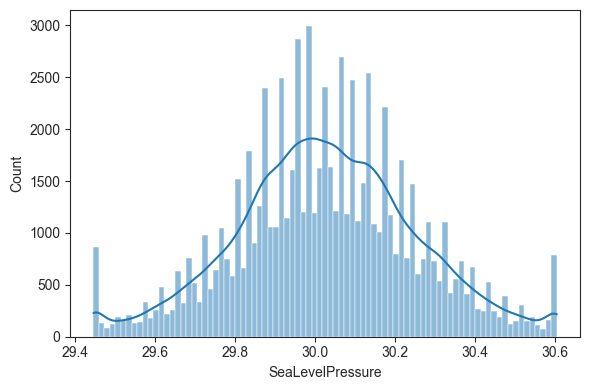

In [46]:
for col in continuous:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col],kde=True)
    plt.tight_layout()

In [47]:
df['VISIBILITY'].skew()


np.float64(-2.972257227903401)

In [48]:
df['VISIBILITY'].min()


np.float64(0.0)

<Axes: xlabel='VISIBILITY', ylabel='Density'>

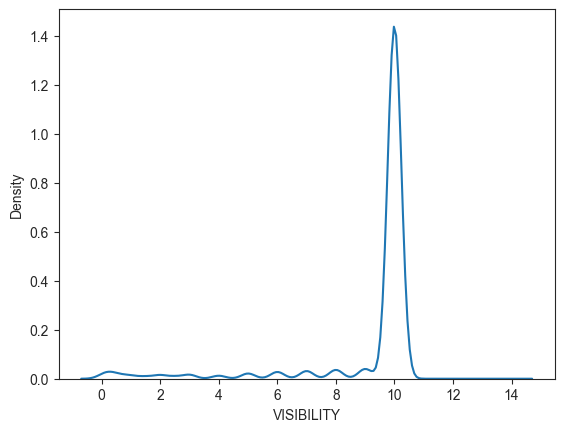

In [49]:
sns.kdeplot(df['VISIBILITY'])


# train test split


In [50]:
df.head()

,VISIBILITY,DRYBULBTEMPF,RelativeHumidity,WindSpeed,WindDirection,SeaLevelPressure,year,month,day,hour
0,6.0,33.0,92.0,0.0,0.0,29.99,2010,1,1,0
1,6.0,33.0,96.0,0.0,0.0,29.99,2010,1,1,1
2,5.0,33.0,96.0,0.0,0.0,29.99,2010,1,1,2
3,5.0,33.0,96.0,0.0,0.0,29.97,2010,1,1,3
4,5.0,33.0,92.0,0.0,0.0,29.96,2010,1,1,4


In [51]:
from sklearn.model_selection import train_test_split
X = df.drop('VISIBILITY',axis=1)
y=df['VISIBILITY']


In [52]:
pip install catboost

  Obtaining dependency information for catboost from https://files.pythonhosted.org/packages/93/e2/f467a133b37eef2b3d8697d46a6e7f0da24bd3643f5475817c473ffc41dc/catboost-1.2.10-cp312-cp312-win_amd64.whl.metadata
  Using cached catboost-1.2.10-cp312-cp312-win_amd64.whl.metadata (1.5 kB)
  Obtaining dependency information for graphviz from https://files.pythonhosted.org/packages/91/4c/e0ce1ef95d4000ebc1c11801f9b944fa5910ecc15b5e351865763d8657f8/graphviz-0.21-py3-none-any.whl.metadata
  Using cached graphviz-0.21-py3-none-any.whl.metadata (12 kB)
  Obtaining dependency information for plotly from https://files.pythonhosted.org/packages/90/ad/cba91b3bcf04073e4d1655a5c1710ef3f457f56f7d1b79dcc3d72f4dd912/plotly-6.7.0-py3-none-any.whl.metadata
  Obtaining dependency information for narwhals>=1.15.1 from https://files.pythonhosted.org/packages/37/72/e61e3091e0e00fae9d3a8ef85ece9d2cd4b5966058e1f2901ce42679eebf/narwhals-2.19.0-py3-none-any.whl.metadata
Using cached catboost-1.2.10-cp312-cp312-win


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [53]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.linear_model import LinearRegression, Ridge,Lasso
from sklearn.model_selection import GridSearchCV

In [54]:
df


,VISIBILITY,DRYBULBTEMPF,RelativeHumidity,WindSpeed,WindDirection,SeaLevelPressure,year,month,day,hour
0,6.0,33.0,92.0,0.0,0.0,29.99,2010,1,1,0
1,6.0,33.0,96.0,0.0,0.0,29.99,2010,1,1,1
2,5.0,33.0,96.0,0.0,0.0,29.99,2010,1,1,2
3,5.0,33.0,96.0,0.0,0.0,29.97,2010,1,1,3
4,5.0,33.0,92.0,0.0,0.0,29.96,2010,1,1,4
...,...,...,...,...,...,...,...,...,...,...
75078,10.0,76.0,88.0,3.0,230.0,30.02,2018,7,27,18
75079,4.0,69.0,100.0,13.0,40.0,30.01,2018,7,27,19
75080,10.0,71.0,96.0,0.0,0.0,30.04,2018,7,27,20
75081,10.0,72.0,94.0,5.0,50.0,30.02,2018,7,27,21


In [55]:
num_column

['DRYBULBTEMPF',
 'RelativeHumidity',
 'WindSpeed',
 'WindDirection',
 'SeaLevelPressure',
 'year',
 'month',
 'day',
 'hour']

In [56]:
cat_column

[]

In [58]:
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.compose import ColumnTransformer

In [59]:
num_transformer = StandardScaler()
oh_transformer = OneHotEncoder()

In [60]:
preprocessor = ColumnTransformer(
    [
        ("OneHotEncoder",oh_transformer,cat_column),
        ("StandardScaler",num_transformer,num_column),
    ]
)

# Scaling

In [61]:
X = preprocessor.fit_transform(X)
X

array([[-1.28522741,  1.36630779, -1.88402623, ..., -1.56024924,
        -1.6732434 , -1.66107872],
       [-1.28522741,  1.56732464, -1.88402623, ..., -1.56024924,
        -1.6732434 , -1.51662396],
       [-1.28522741,  1.56732464, -1.88402623, ..., -1.56024924,
        -1.6732434 , -1.3721692 ],
       ...,
       [ 0.89940651,  1.56732464, -1.88402623, ...,  0.18869243,
         1.28469669,  1.2280165 ],
       [ 0.95689687,  1.46681621, -1.04326543, ...,  0.18869243,
         1.28469669,  1.37247126],
       [ 0.95689687,  1.61757885, -1.88402623, ...,  0.18869243,
         1.28469669,  1.51692602]], shape=(75083, 9))

In [62]:
X_train , X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
X_train.shape , X_test.shape,y_train.shape,y_test.shape

((60066, 9), (15017, 9), (60066,), (15017,))

# Evaluation

In [63]:
def evaluate_model(true,predicted):
    mae = mean_absolute_error(true,predicted)
    mse = mean_squared_error(true,predicted)
    rmse = np.sqrt(mean_squared_error(true,predicted))
    r2_square = r2_score(true,predicted)
    
    return mae, rmse, r2_square

In [64]:
models = {
    "LinearRegression": LinearRegression(),
    "Lasso": Lasso(),
    "Ridge": Ridge(),
    "RandomForestRegressor": RandomForestRegressor(),
    "DecisionTreeRegressor": DecisionTreeRegressor(),
    "XGBRegressor": XGBRegressor(),
    "CatBoostRegressor": CatBoostRegressor(),
    "AdaBoostRegressor": AdaBoostRegressor()
}
model_list = []
r2_list =[]

for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train,y_train) # train model

    # make predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Evaluate train and test dataset
    model_train_mae, model_train_rmse , model_train_r2 = evaluate_model(y_train,y_train_pred)
    model_test_mae, model_test_rmse , model_test_r2 = evaluate_model(y_test,y_test_pred)

    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])

    print('Model performance for training set')
    print("- root mean squared error: {:.4f}".format(model_train_rmse))
    print("-  mean absolute error: {:.4f}".format(model_train_mae))
    print("- r2_score: {:.4f}".format(model_train_r2))

    print('-------------------------------------')

    print('Model performance for test set')
    print("- root mean squared error: {:.4f}".format(model_test_rmse))
    print("-  mean absolute error: {:.4f}".format(model_test_mae))
    print("- r2_score: {:.4f}".format(model_test_r2))
    r2_list.append(model_test_r2)
    
    print("="*35)
    print('\n')

LinearRegression
Model performance for training set
- root mean squared error: 1.8921
-  mean absolute error: 1.2632
- r2_score: 0.2578
-------------------------------------
Model performance for test set
- root mean squared error: 1.9175
-  mean absolute error: 1.2772
- r2_score: 0.2582


Lasso
Model performance for training set
- root mean squared error: 2.1858
-  mean absolute error: 1.3173
- r2_score: 0.0095
-------------------------------------
Model performance for test set
- root mean squared error: 2.2160
-  mean absolute error: 1.3311
- r2_score: 0.0093


Ridge
Model performance for training set
- root mean squared error: 1.8921
-  mean absolute error: 1.2632
- r2_score: 0.2578
-------------------------------------
Model performance for test set
- root mean squared error: 1.9175
-  mean absolute error: 1.2772
- r2_score: 0.2582


RandomForestRegressor
Model performance for training set
- root mean squared error: 0.4102
-  mean absolute error: 0.1661
- r2_score: 0.9651
--------

In [65]:
model_list


['LinearRegression',
 'Lasso',
 'Ridge',
 'RandomForestRegressor',
 'DecisionTreeRegressor',
 'XGBRegressor',
 'CatBoostRegressor',
 'AdaBoostRegressor']

In [66]:
pd.DataFrame(list(zip(model_list,r2_list)),columns=['Model Name', 'R2_Score']).sort_values(by=['R2_Score'],ascending=False)


,Model Name,R2_Score
3,RandomForestRegressor,0.749027
6,CatBoostRegressor,0.725529
5,XGBRegressor,0.721411
4,DecisionTreeRegressor,0.504399
7,AdaBoostRegressor,0.486796
0,LinearRegression,0.258181
2,Ridge,0.258181
1,Lasso,0.009281


# Random Forest Regression


In [67]:
from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor()
rf_model.fit(X_train,y_train)
y_pred = rf_model.predict(X_test)
score = r2_score(y_test,y_pred)*100
print("accuracy is %.2f" %score)

accuracy is 74.61


# Plot y_test and y_pred


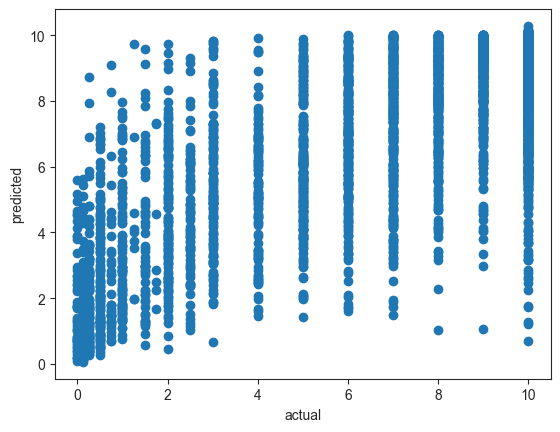

In [68]:
plt.scatter(y_test,y_pred);
plt.xlabel('actual');
plt.ylabel('predicted');

# Difference between Actual and predicted value

In [ ]:

pred_df = pd.DataFrame({'Actual value':y_test,'Predicted Value':y_pred,'Difference': y_test-y_pred})


In [71]:
pred_df

,Actual value,Predicted Value,Difference
71916,10.0,10.0000,0.0000
43178,6.0,9.2800,-3.2800
62285,0.5,0.8775,-0.3775
23073,10.0,10.0000,0.0000
70522,10.0,10.0000,0.0000
...,...,...,...
62761,0.5,2.1095,-1.6095
62593,10.0,9.8300,0.1700
37894,10.0,10.0000,0.0000
53414,10.0,9.5100,0.4900
